In [ ]:
import os
import re
import hashlib
import random
import json
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [ ]:
IMG_SIZE = 196

# Increased from 8 -> 16 for T4
BATCH_SIZE = 16

# Maximum total epochs
STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 20

# Adam is faster to converge than Adadelta
LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-5

L2 = 1e-4

AUGMENT = True
VAL_SPLIT = 0.20
SEED = 42

# Keep ablation OFF for fast training
RUN_ABLATION = False

IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("=" * 70)
print("GPU INFORMATION")
print("=" * 70)

GPU INFORMATION


In [ ]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth setting skipped:", e)
else:
    print("WARNING: No GPU detected!")

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled: mixed_float16")
except Exception as e:
    print("Mixed precision could not be enabled:", e)

Mixed precision enabled: mixed_float16


In [ ]:
import kagglehub

print("\nDownloading / loading PlantVillage...")
plantvillage_path = kagglehub.dataset_download(
    "emmarex/plantdisease"
)
print("PlantVillage:", plantvillage_path)

print("\nDownloading / loading PlantDoc...")
plantdoc_path = kagglehub.dataset_download(
    "abdulhasibuddin/plant-doc-dataset"
)
print("PlantDoc:", plantdoc_path)


Using Colab cache for faster access to the 'plantdisease' dataset.
PlantVillage: /kaggle/input/plantdisease

Using Colab cache for faster access to the 'plant-doc-dataset' dataset.
PlantDoc: /kaggle/input/plant-doc-dataset


In [ ]:
CLASS_NAMES = [
    "bacterial_spot",
    "early_blight",
    "late_blight",
    "leaf_mold",
    "septoria_leaf_spot",
    "spider_mites",
    "target_spot",
    "yellow_leaf_curl_virus",
    "mosaic_virus",
    "healthy",
]

CLASS_TO_ID = {
    c: i for i, c in enumerate(CLASS_NAMES)
}

NUM_CLASSES = len(CLASS_NAMES)

print("\nNumber of classes:", NUM_CLASSES)
print("Classes:")
for i, c in enumerate(CLASS_NAMES):
    print(i, "->", c)


Number of classes: 10
Classes:
0 -> bacterial_spot
1 -> early_blight
2 -> late_blight
3 -> leaf_mold
4 -> septoria_leaf_spot
5 -> spider_mites
6 -> target_spot
7 -> yellow_leaf_curl_virus
8 -> mosaic_virus
9 -> healthy


In [ ]:
def canonical_label(folder_name):

    n = re.sub(r"[_\-]+", " ", folder_name.lower())
    n = re.sub(r"\s+", " ", n).strip()

    if "bacterial" in n:
        return "bacterial_spot"

    if "early" in n:
        return "early_blight"

    if re.search(r"\blate\b", n):
        return "late_blight"

    if "mold" in n:
        return "leaf_mold"

    if "septoria" in n:
        return "septoria_leaf_spot"

    if "spider" in n or "mite" in n:
        return "spider_mites"

    if "target" in n:
        return "target_spot"

    if "curl" in n or "yellow" in n:
        return "yellow_leaf_curl_virus"

    if "mosaic" in n:
        return "mosaic_virus"

    if "healthy" in n or n in ("tomato leaf", "tomato"):
        return "healthy"

    return None

In [ ]:
def collect_tomato_images(root):

    items = []

    for dirpath, _, files in os.walk(root):

        base = os.path.basename(dirpath)

        if "tomato" not in base.lower():
            continue

        imgs = [
            f for f in files
            if f.lower().endswith(IMG_EXT)
        ]

        if not imgs:
            continue

        lab = canonical_label(base)

        if lab is None:
            print(
                f"[skip] unmapped tomato folder: {dirpath}"
            )
            continue

        items += [
            (os.path.join(dirpath, f), lab)
            for f in imgs
        ]

    return items

In [ ]:

def dedupe(items):
    seen = set()
    out = []

    for p, l in items:
        try:
            # Fast duplicate check using file size
            size = os.path.getsize(p)

            # Use filename + size as a lightweight key
            key = (os.path.basename(p).lower(), size)

            if key not in seen:
                seen.add(key)
                out.append((p, l))

        except Exception as e:
            print("Could not read:", p, e)

    return out


print("\nCollecting PlantVillage images...")
pv_items = dedupe(
    collect_tomato_images(plantvillage_path)
)

print("Collecting PlantDoc images...")
pd_items = dedupe(
    collect_tomato_images(plantdoc_path)
)

print("\nPlantVillage images:", len(pv_items))
print("PlantDoc images:", len(pd_items))



PlantVillage images: 16011
PlantDoc images: 731


In [ ]:

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(
    "\nPlantVillage tomato images:",
    len(pv_items)
)

for k, v in sorted(
    Counter(l for _, l in pv_items).items()
):
    print(f"  {k:30s} {v}")

print(
    "\nPlantDoc tomato images:",
    len(pd_items)
)

for k, v in sorted(
    Counter(l for _, l in pd_items).items()
):
    print(f"  {k:30s} {v}")


DATASET INFORMATION

PlantVillage tomato images: 16011
  bacterial_spot                 2127
  early_blight                   1000
  healthy                        1591
  late_blight                    1909
  leaf_mold                      952
  mosaic_virus                   373
  septoria_leaf_spot             1771
  spider_mites                   1676
  target_spot                    1404
  yellow_leaf_curl_virus         3208

PlantDoc tomato images: 731
  bacterial_spot                 107
  early_blight                   83
  healthy                        62
  late_blight                    111
  leaf_mold                      91
  mosaic_virus                   54
  septoria_leaf_spot             148
  yellow_leaf_curl_virus         75


In [ ]:
pv_paths = np.array(
    [p for p, _ in pv_items]
)

pv_labels = np.array(
    [CLASS_TO_ID[l] for _, l in pv_items]
)

te_paths = np.array(
    [p for p, _ in pd_items]
)

te_labels = np.array(
    [CLASS_TO_ID[l] for _, l in pd_items]
)

# =========================
# 13. TRAIN / VALIDATION SPLIT
# =========================

tr_paths, va_paths, tr_labels, va_labels = train_test_split(
    pv_paths,
    pv_labels,
    test_size=VAL_SPLIT,
    stratify=pv_labels,
    random_state=SEED
)

print("\n" + "=" * 70)
print("SPLIT")
print("=" * 70)

print(
    f"Train = {len(tr_paths)}"
)

print(
    f"Validation = {len(va_paths)}"
)

print(
    f"PlantDoc Test = {len(te_paths)}"
)


SPLIT
Train = 12808
Validation = 3203
PlantDoc Test = 731


In [ ]:
augmenter = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal_and_vertical"
        ),

        layers.RandomRotation(
            0.15
        ),

        layers.RandomZoom(
            0.20
        ),

        layers.RandomContrast(
            0.20
        ),
    ],
    name="augmentation"
)


In [ ]:
def _load(path, label):

    img = tf.io.decode_image(
        tf.io.read_file(path),
        channels=3,
        expand_animations=False
    )

    img = tf.image.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = tf.cast(
        img,
        tf.float32
    ) / 255.0

    img.set_shape(
        (IMG_SIZE, IMG_SIZE, 3)
    )

    return img, label

In [ ]:
def make_ds(paths, labels, training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:

        ds = ds.shuffle(
            len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        _load,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    if training and AUGMENT:

        ds = ds.map(
            lambda x, y: (
                tf.clip_by_value(
                    augmenter(
                        x,
                        training=True
                    ),
                    0.0,
                    1.0
                ),
                y
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    return ds.prefetch(
        tf.data.AUTOTUNE
    )

train_ds = make_ds(
    tr_paths,
    tr_labels,
    training=True
)

val_ds = make_ds(
    va_paths,
    va_labels,
    training=False
)

test_ds = make_ds(
    te_paths,
    te_labels,
    training=False
)


In [ ]:
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=tr_labels
)

class_weight = {
    i: float(w)
    for i, w in enumerate(cw)
}

print("\nClass weights:")
print(class_weight)


Class weights:
{0: 0.7529688418577307, 1: 1.601, 2: 0.8387688277668631, 3: 1.6808398950131234, 4: 0.9038814396612562, 5: 0.9551081282624907, 6: 1.1405164737310776, 7: 0.4991426344505066, 8: 4.2979865771812085, 9: 1.006127258444619}


In [ ]:
def rdb(
    x,
    filters=64,
    growth=32,
    n_layers=3,
    alpha=0.3
):

    feats = [x]

    for _ in range(n_layers):

        inp = (
            feats[0]
            if len(feats) == 1
            else layers.Concatenate()(feats)
        )

        feats.append(
            layers.Conv2D(
                growth,
                3,
                padding="same",
                activation="relu"
            )(inp)
        )

    t = layers.Concatenate()(feats)

    t = layers.Conv2D(
        filters,
        3,
        strides=2,
        padding="same"
    )(t)

    t = layers.BatchNormalization()(t)

    t2 = layers.LeakyReLU(
        negative_slope=alpha
    )(t)

    return t2

In [ ]:

def build_rrdn_features(
    inp,
    filters=64
):

    # ---- Part A ----

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inp)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    stem = x

    a = rdb(
        stem,
        filters=filters
    )

    # ---- Part C ----

    c = layers.MaxPooling2D(
        3,
        strides=2,
        padding="same"
    )(stem)

    a = layers.Concatenate()(
        [a, c]
    )

    a = layers.ReLU()(a)

    a = layers.Conv2D(
        filters,
        3,
        padding="same"
    )(a)

    a = layers.BatchNormalization()(a)

    a = layers.ReLU()(a)

    a = layers.Add()(
        [a, c]
    )

    a = layers.MaxPooling2D(
        2
    )(a)

    a = layers.Conv2D(
        128,
        3,
        padding="same",
        activation="relu"
    )(a)

    a = layers.MaxPooling2D(
        2
    )(a)

    # ---- Part B ----

    b = layers.Conv2D(
        128,
        3,
        padding="same"
    )(inp)

    for _ in range(3):

        b = layers.MaxPooling2D(
            2
        )(b)

    a = layers.Add()(
        [a, b]
    )
    features = layers.GlobalAveragePooling2D()(
        a
    )

    return features

In [ ]:
print("\nLoading pretrained ResNet50...")

resnet_base = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

# Initially freeze entire ResNet50
resnet_base.trainable = False

print(
    "ResNet50 loaded with ImageNet weights."
)

print(
    "ResNet50 initially frozen."
)


Loading pretrained ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 loaded with ImageNet weights.
ResNet50 initially frozen.


In [ ]:
def build_hybrid_model():

    inp = layers.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        ),
        name="tomato_input"
    )

    # ------------------------------------------------
    # RRDN branch
    # ------------------------------------------------

    rrdn_features = build_rrdn_features(
        inp
    )

    # ------------------------------------------------
    # ResNet50 branch
    # ------------------------------------------------

    # ResNet50 expects its own preprocessing.
    # Convert [0,1] -> [0,255] and apply preprocess_input.

    resnet_input = layers.Lambda(
        lambda x:
        tf.keras.applications.resnet50.preprocess_input(
            x * 255.0
        ),
        name="resnet_preprocessing"
    )(inp)

    resnet_features = resnet_base(
        resnet_input,
        training=False
    )

    resnet_features = layers.GlobalAveragePooling2D(
        name="resnet_gap"
    )(resnet_features)

    # ------------------------------------------------
    # Feature fusion
    # ------------------------------------------------

    fused = layers.Concatenate(
        name="feature_fusion"
    )(
        [
            rrdn_features,
            resnet_features
        ]
    )

    # ------------------------------------------------
    # Classification head
    # ------------------------------------------------

    fused = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2)
    )(fused)

    fused = layers.BatchNormalization()(
        fused
    )

    fused = layers.Dropout(
        0.40
    )(fused)

    # IMPORTANT:
    # float32 output for numerical stability with mixed precision

    output = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        dtype="float32",
        name="disease_output"
    )(fused)

    model = models.Model(
        inp,
        output,
        name="RRDN_ResNet50_Hybrid"
    )

    return model

In [ ]:
model = build_hybrid_model()

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

model.summary()


MODEL SUMMARY


Model: "RRDN_ResNet50_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tomato_input        │ (None, 196, 196,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 196, 196,  │      1,792 │ tomato_input[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 196, 196,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 196, 196,  │     18,464 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 196, 196,  │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 96)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 196, 196,  │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 196, 196,  │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 128)              │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 196, 196,  │     36,896 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 196, 196,  │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │ 160)              │            │ conv2d_2[0][0],   │
│                     │                   │            │ conv2d_3[0][0],   │
│                     │                   │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 98, 98,    │     92,224 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 98, 98,    │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 98, 98,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 98, 98,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 98, 98,    │          0 │ leaky_re_lu[0][0… │
│ (Concatenate)       │ 128)              │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 98, 98,    │          0 │ concatenate_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 98, 98,    │     73,792 │ re_lu[0][0]     

 Total params: 24,514,346 (93.51 MB)

 Trainable params: 925,866 (3.53 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

In [ ]:
optimizer_stage1 = tf.keras.optimizers.Adam(
    learning_rate=LR_STAGE1
)

model.compile(
    optimizer=optimizer_stage1,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# 24. CALLBACKS
# =========================

callbacks_stage1 = [

    tf.keras.callbacks.ModelCheckpoint(
        "rrdn_resnet50_stage1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# ================================================================
# 25. STAGE 1 TRAINING
# ================================================================

print("\n")
print("=" * 70)
print("STAGE 1: RRDN + FROZEN PRETRAINED RESNET50")
print("=" * 70)



STAGE 1: RRDN + FROZEN PRETRAINED RESNET50


In [ ]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks_stage1,
    verbose=1
)

print("\n")
print("=" * 70)
print("STAGE 2: FINE-TUNING LAST RESNET50 LAYERS")
print("=" * 70)

Epoch 1/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.7142 - loss: 0.9912
Epoch 1: val_accuracy improved from None to 0.75180, saving model to rrdn_resnet50_stage1_best.keras

Epoch 1: finished saving model to rrdn_resnet50_stage1_best.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 344s 322ms/step - accuracy: 0.8040 - loss: 0.6730 - val_accuracy: 0.7518 - val_loss: 0.8545 - learning_rate: 0.0010
Epoch 2/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8813 - loss: 0.4373
Epoch 2: val_accuracy improved from 0.75180 to 0.80862, saving model to rrdn_resnet50_stage1_best.keras

Epoch 2: finished saving model to rrdn_resnet50_stage1_best.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 179s 223ms/step - accuracy: 0.8817 - loss: 0.4211 - val_accuracy: 0.8086 - val_loss: 0.7657 - learning_rate: 0.0010
Epoch 3/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.8883 - loss: 0.4021
Epoch 3: val_accuracy did not improve from 0.80862
801/801 ━━━━━━━━━━━━━━━━━━━━ 181s 225ms/step - accuracy:

In [ ]:
# Unfreeze ResNet50
resnet_base.trainable = True

# Freeze most of ResNet50.
# Only last ~30 layers will be trainable.
for layer in resnet_base.layers[:-30]:
    layer.trainable = False

# Keep BatchNorm layers frozen for stable transfer learning.
for layer in resnet_base.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

trainable_resnet_layers = sum(
    1
    for layer in resnet_base.layers
    if layer.trainable
)

print(
    "Trainable ResNet50 layers:",
    trainable_resnet_layers
)

Trainable ResNet50 layers: 21


In [ ]:
# Recompile after changing trainable status.

optimizer_stage2 = tf.keras.optimizers.Adam(
    learning_rate=LR_STAGE2
)

model.compile(
    optimizer=optimizer_stage2,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage2 = [

    tf.keras.callbacks.ModelCheckpoint(
        "rrdn_resnet50_final_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE2_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9433 - loss: 0.2251
Epoch 1: val_accuracy improved from None to 0.90509, saving model to rrdn_resnet50_final_best.keras

Epoch 1: finished saving model to rrdn_resnet50_final_best.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 240s 263ms/step - accuracy: 0.9472 - loss: 0.2154 - val_accuracy: 0.9051 - val_loss: 0.4066 - learning_rate: 1.0000e-05
Epoch 2/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9504 - loss: 0.1957
Epoch 2: val_accuracy improved from 0.90509 to 0.91820, saving model to rrdn_resnet50_final_best.keras

Epoch 2: finished saving model to rrdn_resnet50_final_best.keras
801/801 ━━━━━━━━━━━━━━━━━━━━ 190s 236ms/step - accuracy: 0.9532 - loss: 0.1962 - val_accuracy: 0.9182 - val_loss: 0.3618 - learning_rate: 1.0000e-05
Epoch 3/20
801/801 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9592 - loss: 0.1783
Epoch 3: val_accuracy improved from 0.91820 to 0.95223, saving model to rrdn_resnet50_final_best.keras


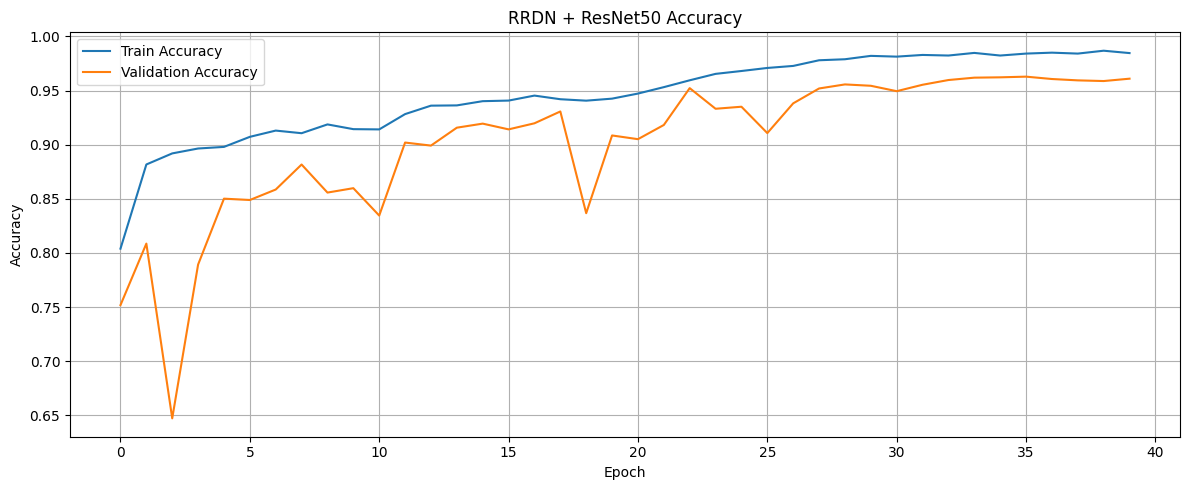

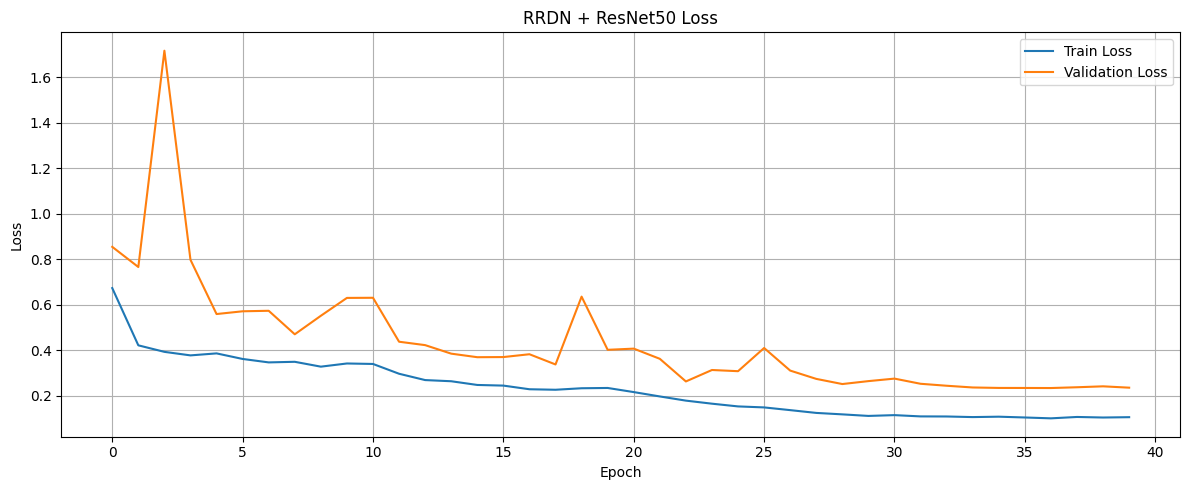

In [ ]:
history = {}

for key in history1.history.keys():

    history[key] = (
        history1.history[key]
        +
        history2.history.get(
            key,
            []
        )
    )

# ================================================================
# 28. PLOT TRAINING CURVES
# ================================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "RRDN + ResNet50 Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "rrdn_resnet50_accuracy.png",
    dpi=150
)

plt.show()

# =========================
# LOSS
# =========================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    history["loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "RRDN + ResNet50 Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "rrdn_resnet50_loss.png",
    dpi=150
)

plt.show()

In [ ]:
print("\n")
print("=" * 70)
print("PLANTVILLAGE VALIDATION")
print("=" * 70)

val_loss, val_acc = model.evaluate(
    val_ds,
    verbose=1
)

print(
    f"\nPlantVillage validation accuracy: "
    f"{val_acc * 100:.2f}%"
)

print(
    f"PlantVillage validation loss: "
    f"{val_loss:.4f}"
)



PLANTVILLAGE VALIDATION
201/201 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9628 - loss: 0.2335

PlantVillage validation accuracy: 96.28%
PlantVillage validation loss: 0.2335


In [ ]:
def evaluate_on_plantdoc(
    model,
    verbose=True
):

    print("\nPredicting PlantDoc...")

    probs = model.predict(
        test_ds,
        verbose=1
    )

    y_pred = probs.argmax(
        axis=1
    )

    y_true = te_labels

    acc = accuracy_score(
        y_true,
        y_pred
    )

    if verbose:

        print("\n")
        print("=" * 70)
        print("PLANTDOC TEST RESULTS")
        print("=" * 70)

        print(
            f"\nPlantDoc tomato TEST "
            f"top-1 accuracy: "
            f"{acc * 100:.2f}%"
        )

        print(
            f"Number of PlantDoc images: "
            f"{len(y_true)}"
        )

        present = sorted(
            set(y_true)
        )

        print("\nClassification Report:\n")

        print(
            classification_report(
                y_true,
                y_pred,
                labels=present,
                target_names=[
                    CLASS_NAMES[i]
                    for i in present
                ],
                zero_division=0,
                digits=4
            )
        )

        # ------------------------------------------------
        # Confusion Matrix
        # ------------------------------------------------

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(
                range(NUM_CLASSES)
            )
        )

        plt.figure(
            figsize=(10, 8)
        )

        plt.imshow(
            cm,
            cmap="Blues"
        )

        plt.colorbar()

        plt.xticks(
            range(NUM_CLASSES),
            CLASS_NAMES,
            rotation=90
        )

        plt.yticks(
            range(NUM_CLASSES),
            CLASS_NAMES
        )

        plt.xlabel(
            "Predicted"
        )

        plt.ylabel(
            "True"
        )

        plt.title(
            "RRDN + ResNet50 PlantDoc Confusion Matrix"
        )

        plt.tight_layout()

        plt.savefig(
            "rrdn_resnet50_confusion_matrix.png",
            dpi=150
        )

        plt.show()

    return acc


Predicting PlantDoc...
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 419ms/step


PLANTDOC TEST RESULTS

PlantDoc tomato TEST top-1 accuracy: 25.31%
Number of PlantDoc images: 731

Classification Report:

                        precision    recall  f1-score   support

        bacterial_spot     0.1017    0.0561    0.0723       107
          early_blight     0.2200    0.5301    0.3110        83
           late_blight     0.2572    0.8018    0.3895       111
             leaf_mold     0.2000    0.0330    0.0566        91
    septoria_leaf_spot     0.4321    0.2365    0.3057       148
yellow_leaf_curl_virus     0.4545    0.0667    0.1163        75
          mosaic_virus     0.0000    0.0000    0.0000        54
               healthy     0.3000    0.0484    0.0833        62

             micro avg     0.2559    0.2531    0.2545       731
             macro avg     0.2457    0.2216    0.1668       731
          weighted avg     0.2634    0.2531    0.1930       731



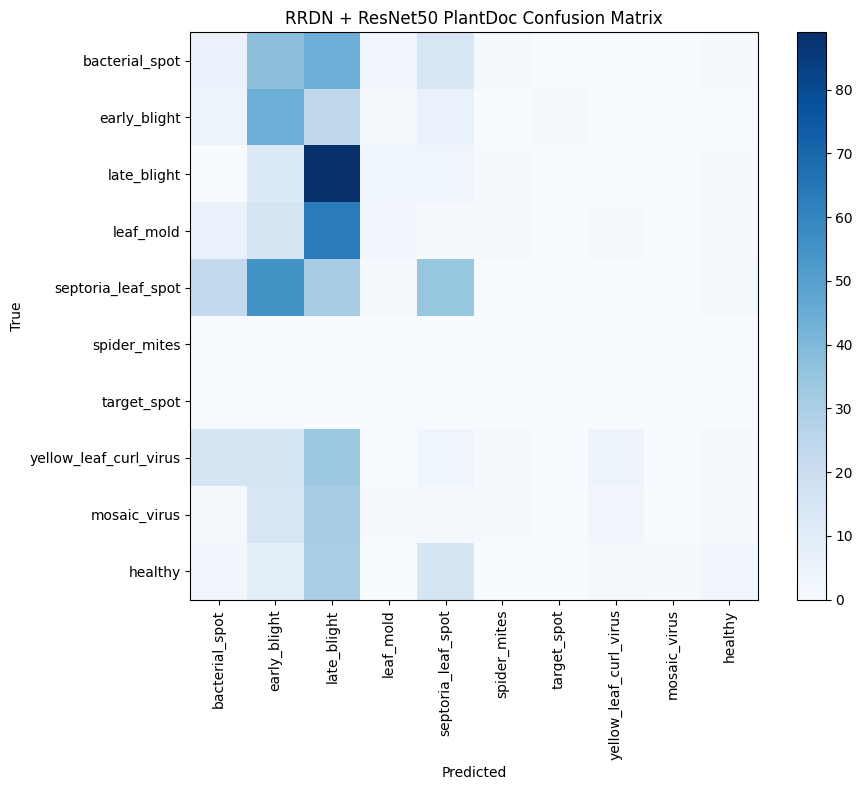

In [ ]:
test_acc = evaluate_on_plantdoc(
    model,
    verbose=True
)

In [ ]:
model.save(
    "rrdn_resnet50_tomato_final.keras"
)

print("\n")
print("=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    "rrdn_resnet50_tomato_final.keras"
)



MODEL SAVED
rrdn_resnet50_tomato_final.keras


In [ ]:
results = {

    "model":
        "RRDN + ResNet50 Hybrid",

    "image_size":
        IMG_SIZE,

    "batch_size":
        BATCH_SIZE,

    "stage1_epochs":
        len(history1.history["loss"]),

    "stage2_epochs":
        len(history2.history["loss"]),

    "total_epochs":
        len(history["loss"]),

    "plantvillage_validation_accuracy":
        float(val_acc),

    "plantdoc_test_accuracy":
        float(test_acc),

    "optimizer":
        "Adam",

    "resnet_pretrained":
        True,

    "resnet_initially_frozen":
        True,

    "augmentation":
        AUGMENT,

    "class_weight":
        True,

    "mixed_precision":
        True
}

with open(
    "rrdn_resnet50_results.json",
    "w"
) as f:

    json.dump(
        results,
        f,
        indent=2
    )

In [ ]:
print("\nFinal results:")
print(
    json.dumps(
        results,
        indent=2
    )
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)


Final results:
{
  "model": "RRDN + ResNet50 Hybrid",
  "image_size": 196,
  "batch_size": 16,
  "stage1_epochs": 20,
  "stage2_epochs": 20,
  "total_epochs": 40,
  "plantvillage_validation_accuracy": 0.9628473520278931,
  "plantdoc_test_accuracy": 0.253077975376197,
  "optimizer": "Adam",
  "resnet_pretrained": true,
  "resnet_initially_frozen": true,
  "augmentation": true,
  "class_weight": true,
  "mixed_precision": true
}

TRAINING COMPLETE
